In [5]:
import sys, os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

os.environ.setdefault("DJANGO_SETTINGS_MODULE", "config.settings")
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"

import django
django.setup()

In [6]:
import os
import django

os.environ.setdefault("DJANGO_SETTINGS_MODULE", "config.settings")
django.setup()

import pandas as pd
import matplotlib.pyplot as plt

from data_engine.models import SerieHistoricaDeuda

df = pd.DataFrame(SerieHistoricaDeuda.objects.all().values())

# Los campos Decimal de Postgres llegan como objetos Decimal; los convertimos
# a float para que matplotlib pueda graficarlos sin problemas.
df["monto_millones"] = df["monto_millones"].astype(float)
df["pct_pib"] = df["pct_pib"].astype(float)

df = df.sort_values("anio")
df.head()

,id,anio,fecha_corte,tipo_deuda,moneda,monto_millones,pct_pib,es_corte_parcial,fuente,fecha_carga
0,2,1991,1991-12-31,bruta,clp,4937066.0,0.373662,False,hacienda_series_historicas_deuda,2026-09-09 18:16:07.496218+00:00
1,1,1991,1991-12-31,bruta,usd,13170.0,0.373662,False,hacienda_series_historicas_deuda,2026-09-09 18:16:07.488681+00:00
2,4,1991,1991-12-31,neta,clp,2972446.0,0.224969,False,hacienda_series_historicas_deuda,2026-09-09 18:16:07.498218+00:00
3,3,1991,1991-12-31,neta,usd,7929.0,0.224969,False,hacienda_series_historicas_deuda,2026-09-09 18:16:07.497218+00:00
4,6,1992,1992-12-31,bruta,clp,5117626.0,0.307075,False,hacienda_series_historicas_deuda,2026-09-09 18:16:07.500743+00:00


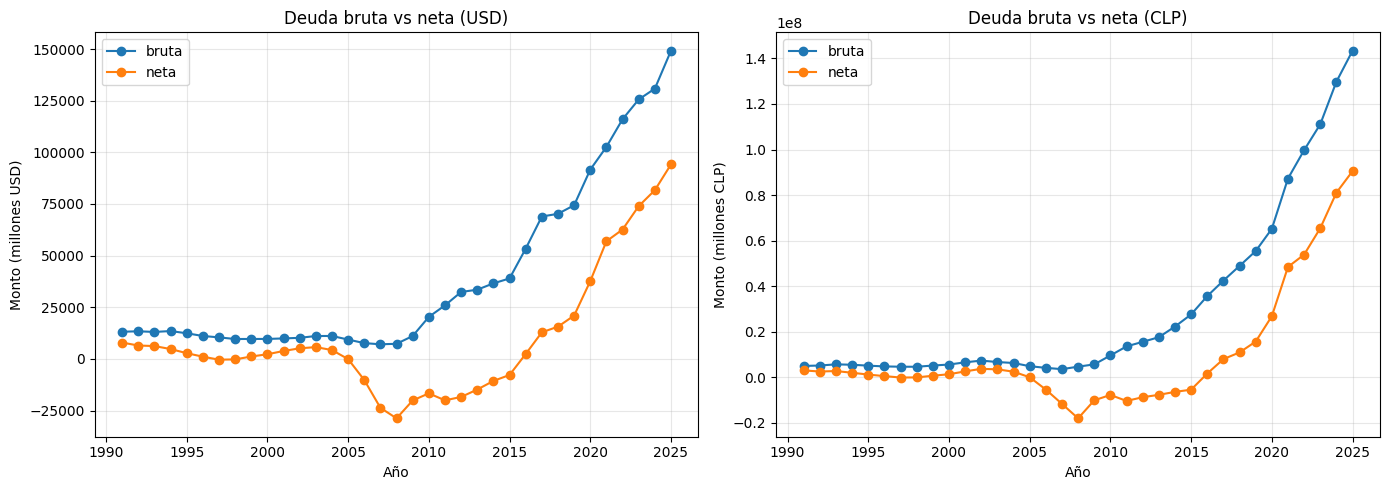

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for ax, moneda, titulo in zip(axes, ["usd", "clp"], ["USD", "CLP"]):
    sub = df[df["moneda"] == moneda]
    for tipo in ["bruta", "neta"]:
        serie = sub[sub["tipo_deuda"] == tipo]
        ax.plot(serie["anio"], serie["monto_millones"], marker="o", label=tipo)
    ax.set_title(f"Deuda bruta vs neta ({titulo})")
    ax.set_xlabel("Año")
    ax.set_ylabel(f"Monto (millones {titulo})")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

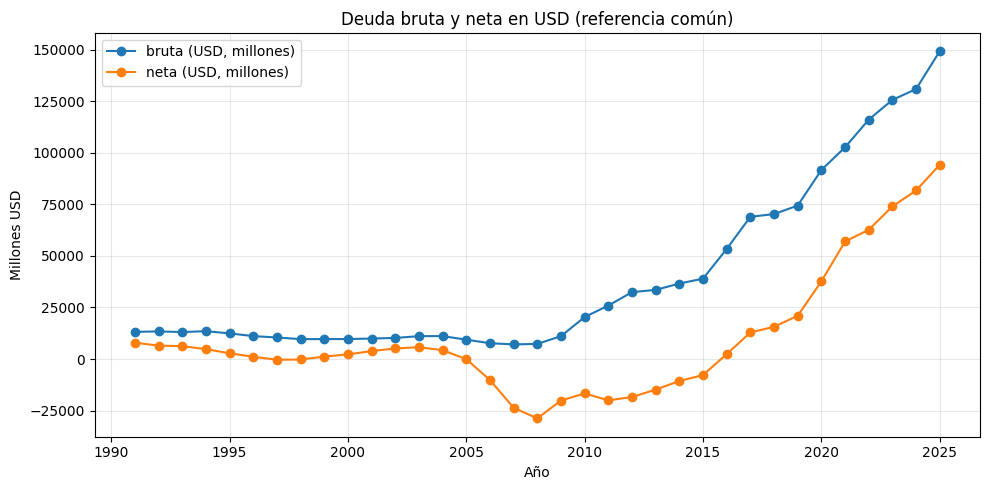

In [8]:
pivot = df.pivot_table(
    index=["anio", "tipo_deuda"], columns="moneda", values="monto_millones"
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
for tipo in ["bruta", "neta"]:
    sub = pivot[pivot["tipo_deuda"] == tipo]
    ax.plot(sub["anio"], sub["usd"], marker="o", label=f"{tipo} (USD, millones)")

ax.set_xlabel("Año")
ax.set_ylabel("Millones USD")
ax.set_title("Deuda bruta y neta en USD (referencia común)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

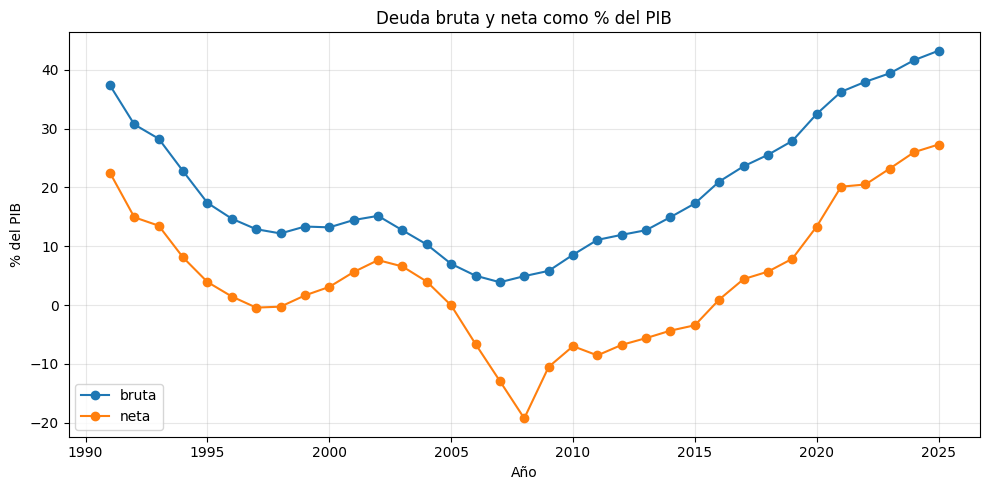

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

sub = df[df["moneda"] == "usd"]  # pct_pib es igual en usd y clp, basta una moneda
for tipo in ["bruta", "neta"]:
    serie = sub[sub["tipo_deuda"] == tipo]
    ax.plot(serie["anio"], serie["pct_pib"] * 100, marker="o", label=tipo)

ax.set_xlabel("Año")
ax.set_ylabel("% del PIB")
ax.set_title("Deuda bruta y neta como % del PIB")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()